# DEVP 209 Section 5

In this lab, we will be using Python and Pandas to understand Bayes' rule of conditional probability and also apply conditionality to use indicator variables

## Imports

In [1]:
import pandas as pd                 # We can give aliases to packages; can call it whatever I want to save typing
import datetime                     # This allows me to use dates
import numpy as np                  # This is the second most popular package after Pandas most likely
import statsmodels.api as sm        # Used for regressions
import  matplotlib.pyplot as plt    # Plotting library

### Practicing Bayes' rule

First, let us see something about how a dataset is represented

In [2]:
arrests = pd.read_csv('arrests.csv')
print(len(arrests))
arrests.head()

265226


,Apprehension Date,Apprehension State,Departed Date,Departure Country,Birth Year,Citizenship Country,Gender
0,08/07/2024 9:43,VIRGINIA,08/19/2024,HONDURAS,1981,HONDURAS,Male
1,10/19/2024 20:33,TEXAS,10/22/2024,MEXICO,1984,MEXICO,Male
2,04/15/2025 10:08,NEW JERSEY,06/10/2025,DOMINICAN REPUBLIC,1988,DOMINICAN REPUBLIC,Male
3,06/03/2025 9:20,MINNESOTA,NaN,NaN,1985,COLOMBIA,Female
4,01/21/2025 17:41,NaN,02/01/2025,MEXICO,1983,MEXICO,Male


I have a dataset of removals from our ICE data work (https://deportationdata.org/data/ice.html)
Let us see what happens when I do some of the filtering in Pandas that we have already learned

In [3]:
(arrests['Departure Country'] == 'MEXICO')

0         False
1          True
2         False
3         False
4          True
          ...  
265221    False
265222    False
265223    False
265224    False
265225    False
Name: Departure Country, Length: 265226, dtype: bool

So it seems that if I do a check for if the `'Departure Country'` column is equal to the value of `'MEXICO'` then I get a list of `True` and `False` values. This is simply checking every single row in this column and letting us know whether or not our check is right or wrong. Something interesting though happens when I do the following

IMPORTANT TO NOTE: `True` when used in math is the same as 1 and `False` is the same as 0

In [4]:
(arrests['Departure Country'] == 'MEXICO').sum()

73037

Here I see that there are 72,691 different removals for people from Mexico. Above, I can also see that there 144,176 different rows. This means that I can simply do a sum here and divide by all of the rows to see the probability of being a Mexican out of the people that are removed. This is shown below

In [5]:
probabilityOfMexicanArrest = (arrests['Departure Country'] == 'MEXICO').sum()/len(arrests)
print(probabilityOfMexicanArrest)

0.2753764713866665


Another way we can do this is simply taking the mean value. This can be interpreted simply since we have a bunch of `True` values that equal 1, then we are finding the average number of 1s which is the same as the probability

In [6]:
probabilityOfMexicanArrest2 = (arrests['Departure Country'] == 'MEXICO').mean()
print(probabilityOfMexicanArrest2)

0.2753764713866665


This is our first real introduction on how we can use filtering to find probabilities in data.

Below we are going to go through some exercises to practice using the above information to see Bayes' rule using a new set of data: removals.

It is so long that it actually was split into two lol so we need to combine them as below

In [7]:
removals = pd.read_csv('removals.csv')
removals.head()

,Departed Date,Port of Departure,Departure Country,Gender,Citizenship Country,Birth Year,Entry Date,Entry Status,Felon,Final Program,Prior Deport Yes No,Latest Person Departed Date
0,07/04/2024,"NOGALES, AZ, POE",MEXICO,Male,MEXICO,1991.0,06/05/2024,PWA Mexico,NaN,Border Patrol,YES,07/04/2024
1,09/09/2023,"CALEXICO, CA, POE",MEXICO,Male,MEXICO,1995.0,06/15/2023,PWA Mexico,NaN,Border Patrol,YES,09/09/2023
2,09/09/2023,"NOGALES, AZ, POE",MEXICO,Female,MEXICO,1993.0,08/22/2023,PWA Mexico,NaN,Border Patrol,YES,09/09/2023
3,06/25/2024,"HARLINGEN, TX, POE",COLOMBIA,Male,COLOMBIA,2000.0,06/09/2024,PWA Mexico,NaN,Border Patrol,NO,06/25/2024
4,04/02/2025,"NOGALES, AZ, POE",MEXICO,Male,MEXICO,1980.0,11/27/2024,Other Applicant for Admission,Not an Aggravated Felon,Inspections - Land,NO,04/02/2025


In [8]:
removals.Felon.unique()

array([nan, 'Not an Aggravated Felon', 'Drugs', 'Other',
       'Both (drug and other agg felon convictions)'], dtype=object)

Let us now try to answer some questions about our dataset to understand the population
* What is the sample space of Departure Countries?
* What is the Probability of being older than 30?
* What is the number of rows that represent the Union of people from COLOMBIA and those that have had a prior deportation?
* What is the number of rows that represent the Intersection of People born after 2000 that are Female?
* What is the complement to the above question?
* What is the probability that a removed person was `'Not an Aggravated Felon'` OR has nothing listed for the felony charge? Hint: OR in Pandas is `|` and you will need to try `pd.isnull(removals['Felon'])`

Now we will try to answer some questions about probability and use Bayes' rule; first look at the given example

In [9]:
# Probability male
P_A = (removals['Departure Country'] == 'MEXICO').mean()
P_B = (removals['Gender'] == 'Male').mean()

# Probability male and mexican
P_AB = ((removals['Departure Country'] == 'MEXICO') & (removals['Gender'] == 'Male')).sum()/len(removals)

# Likelihood: P(MEXICO | MALE) = P(MEXICO AND MALE) * P(MEXICO)/P(MALE)
conditional_AB = P_AB *P_A/ P_B
# Likelihood: P(Male | MEXICO)
conditional_BA = P_AB *P_B/ P_A

print(conditional_AB)
print(conditional_BA)


0.1507113092770203
0.7024344698273849


This means that 15% of Male removals are to Mexico and 70% of people removed to Mexico are Male!

In [10]:
len(arrests.loc[arrests['Gender']=='Female'])

33794

In [11]:
# We can do this again by doing the powerful groupby command we have learned in prior classes
arrests.groupby('Gender')['Departure Country'].value_counts(normalize=True)

# What is happening here is we are counting the total number of people in each country for each gender, then 'normalizing' which means dividing by the total number
# In practice, this means that we have for instance 3721 Females deported from Mexico, but 33794 total females, giving a conditional probability of 3721/33794 = 38.8%

Gender   Departure Country       
Female   MEXICO                      0.388413
         HONDURAS                    0.139353
         GUATEMALA                   0.125470
         EL SALVADOR                 0.068476
         COLOMBIA                    0.056159
                                       ...   
Unknown  ST. LUCIA                   0.001412
         TRINIDAD AND TOBAGO         0.001412
         TURKS AND CAICOS ISLANDS    0.001412
         UNITED KINGDOM              0.001412
         VIETNAM                     0.001412
Name: Departure Country, Length: 311, dtype: float64

Let us now try to figure out some conditional values in our dataset
* What is probability of a female removed if they are younger than 30?
* What is the probability of being a Venezuelan detained if their Final Program was Border Patrol?
* What is the odds that they had a prior departure if they have Felon value of '`Drugs`'?
* What are the odds that people that are not from Mexico are sent to Mexico?
* How much more/less likely are Males to have a Felon value of `'Drugs'` than females? Challenge: How does this vary by country and which country has the greatest discrepancy?

## Challenge Section: Regressing using indicator variables

Let us now use the ArrestsByState data and determine how OLS changes with the presence of an indicator variable

### Step 0: Import the data

In [12]:
arrests_state_country = pd.read_csv('ArrestsStateCountry.csv', sep='\t')
arrests_state_country.head()

,apprehensionstate,citizenshipcountry,arrestsbiden,arrests_perdaybiden,arreststrump,arrests_perdaytrump,popACS2023,popACS2024,ln2023,ln2024,predicted,predicted_level,pop_combined,pct_peryear_biden,pct_peryear_trump
0,ALABAMA,BRAZIL,1.0,0.001976,2.0,0.010526,1646.0,NaN,7.406104,NaN,7.751637,2325.376,2325.376,0.000310,0.001652
1,ALABAMA,CHINA,10.0,0.019763,3.0,0.015790,10355.0,NaN,9.245225,NaN,9.263822,10549.370,10549.370,0.000684,0.000546
2,ALABAMA,COLOMBIA,33.0,0.065217,19.0,0.100000,2949.0,NaN,7.989222,NaN,8.436029,4610.213,4610.213,0.005163,0.007917
3,ALABAMA,CUBA,14.0,0.027668,15.0,0.078947,2740.0,NaN,7.915713,NaN,8.358318,4265.516,4265.516,0.002367,0.006756
4,ALABAMA,DOMINICAN REPUBLIC,11.0,0.021739,7.0,0.036842,1701.0,NaN,7.438972,NaN,7.441265,1704.906,1704.906,0.004654,0.007888


### Step 1: Create a scatter plot that is not a time series

First step is creating a dataframe that simply relates two numerical values that ~might~ be related

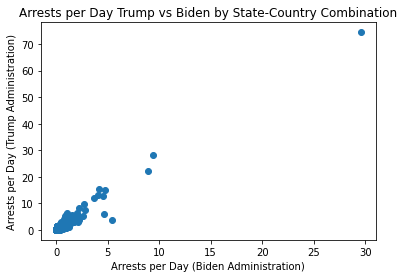

In [13]:
plt.scatter(arrests_state_country['arrests_perdaybiden'], 
           arrests_state_country['arrests_perdaytrump'])

# we can also add titles as follows
plt.ylabel('Arrests per Day (Trump Administration)')
plt.xlabel('Arrests per Day (Biden Administration)')
plt.title('Arrests per Day Trump vs Biden by State-Country Combination')
plt.show()

### Step 2: Add an indicator variable

As we learned in class, an indicator variable is a column of 1s and 0s. I am making an indicator variable for if a country is in Europe

In [14]:
# I Googled these
european_countries = ['GERMANY', 'FRANCE', 'ITALY', 'SPAIN', 'PORTUGAL', 'POLAND', 'NETHERLANDS',
                      'BELGIUM', 'SWEDEN', 'NORWAY', 'DENMARK', 'FINLAND', 'ICELAND', 'IRELAND',
                      'GREECE', 'AUSTRIA', 'SWITZERLAND', 'HUNGARY', 'CZECH REPUBLIC', 'SLOVAKIA',
                      'SLOVENIA', 'CROATIA', 'SERBIA', 'ROMANIA', 'BULGARIA', 'ESTONIA', 'LATVIA', 'LITHUANIA', 'UKRAINE', 'RUSSIA', 'TURKEY']

arrests_state_country['European'] = (arrests_state_country['citizenshipcountry'].isin(european_countries)).astype(int)
arrests_state_country.head()


,apprehensionstate,citizenshipcountry,arrestsbiden,arrests_perdaybiden,arreststrump,arrests_perdaytrump,popACS2023,popACS2024,ln2023,ln2024,predicted,predicted_level,pop_combined,pct_peryear_biden,pct_peryear_trump,European
0,ALABAMA,BRAZIL,1.0,0.001976,2.0,0.010526,1646.0,NaN,7.406104,NaN,7.751637,2325.376,2325.376,0.000310,0.001652,0
1,ALABAMA,CHINA,10.0,0.019763,3.0,0.015790,10355.0,NaN,9.245225,NaN,9.263822,10549.370,10549.370,0.000684,0.000546,0
2,ALABAMA,COLOMBIA,33.0,0.065217,19.0,0.100000,2949.0,NaN,7.989222,NaN,8.436029,4610.213,4610.213,0.005163,0.007917,0
3,ALABAMA,CUBA,14.0,0.027668,15.0,0.078947,2740.0,NaN,7.915713,NaN,8.358318,4265.516,4265.516,0.002367,0.006756,0
4,ALABAMA,DOMINICAN REPUBLIC,11.0,0.021739,7.0,0.036842,1701.0,NaN,7.438972,NaN,7.441265,1704.906,1704.906,0.004654,0.007888,0


### Step 3: Regress on the indicator variable

In [15]:
arrests_state_country = arrests_state_country.dropna(subset=['arrests_perdaybiden','arrests_perdaytrump'])

In [16]:
# Define regression: arrests_perdaytrump ~ arrests_perdaybiden + European
X = arrests_state_country[["arrests_perdaybiden", "European"]]
X = sm.add_constant(X) # This is the same as adding a column of all 1s to the country_stats dataframe called 'intercept' and including that in the above selected columns
y = arrests_state_country['arrests_perdaytrump']

model = sm.OLS(y, X).fit()
print(model.summary())

                             OLS Regression Results                            
Dep. Variable:     arrests_perdaytrump   R-squared:                       0.956
Model:                             OLS   Adj. R-squared:                  0.956
Method:                  Least Squares   F-statistic:                     8255.
Date:                 Wed, 01 Oct 2025   Prob (F-statistic):               0.00
Time:                         20:16:07   Log-Likelihood:                -805.97
No. Observations:                  759   AIC:                             1618.
Df Residuals:                      756   BIC:                             1632.
Df Model:                            2                                         
Covariance Type:             nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   

### Challenge 1: Interpret the indicator variable and the intercept

### Challenge 2: Add an indicator variable on the slope

### Challenge 3: Plot the above using what you had done in section 4